# 36.2 · Hungarian assignment and gating

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain hungarian assignment and gating using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[18 · Object Tracking](../../18-object-tracking/README.md), [27 · Object Detection](../../27-object-detection/README.md), [35 · Optical Flow](../../35-optical-flow/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Multi-object tracking maintains several identities across detections. It combines prediction, association, creation and deletion policies. Detection quality, occlusion and object similarity all affect identity continuity.

## 2. Intuition

The Hungarian algorithm finds a minimum-cost assignment in a cost matrix. Costs can use center distance, box overlap or appearance distance. Gating excludes implausible pairs before accepting assignments. Unmatched tracks predict through short gaps and expire after a declared lifetime.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 36
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\min_A\sum_{ij}A_{ij}C_{ij}
$$

Cij is the cost of assigning track i to detection j, and Aij is 1 when that assignment is selected. Each track and detection may appear at most once. Costs [[1,9],[8,2]] favor the diagonal with total cost 3.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
from scipy.optimize import linear_sum_assignment

cost = np.array([[1.0, 9.0], [8.0, 2.0]])
rows, columns = linear_sum_assignment(cost)
total = cost[rows, columns].sum()
assert total == 3
print(rows, columns, total)

[0 1] [0 1] 3.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The shared tracker performs prediction, gated Hungarian association and Joseph-form covariance correction. The synthetic lab introduces missed observations and reports a limited nearest-truth identity diagnostic.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def multi_tracking(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    tracker = KalmanTracker(gate=18, max_missed=4)
    frames = 32
    paths = [[], []]
    switches = 0
    previous = {}
    for t in range(frames):
        true = np.array([[10 + 2 * t, 24 + 0.2 * t], [80 - 1.8 * t, 62 - 0.4 * t]])
        detections = true + rng.normal(0, amount, true.shape)
        if lesson > 0 and 12 <= t <= 14:
            detections = detections[1:]
        tracks = tracker.update(detections)
        for obj in range(2):
            if tracks:
                track = min(tracks, key=lambda tr: np.linalg.norm(tr.state[:2] - true[obj]))
                if np.linalg.norm(track.state[:2] - true[obj]) < 8:
                    if obj in previous and previous[obj] != track.identity:
                        switches += 1
                    previous[obj] = track.identity
                    paths[obj].append(track.state[:2].copy())
    return Result(
        "36 · Assignment, prediction and track IDs",
        curves={f"Track for truth object {i} (x→y)": np.array(p) for i, p in enumerate(paths)},
        metrics={
            "frames": frames,
            "nearest_truth_id_switches": switches,
            "final_active_tracks": len(tracker.tracks),
        },
        notes="Two well separated generated trajectories. This is a center-only Kalman/Hungarian teaching tracker, not a full SORT or DeepSORT implementation. Nearest-truth association is a toy diagnostic, not HOTA or IDF1.",
    )

{
  "frames": 32,
  "nearest_truth_id_switches": 0,
  "final_active_tracks": 2
}
Two well separated generated trajectories. This is a center-only Kalman/Hungarian teaching tracker, not a full SORT or DeepSORT implementation. Nearest-truth association is a toy diagnostic, not HOTA or IDF1.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/tracking.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.tracking import KalmanTracker

display(Code(inspect.getsource(KalmanTracker), language="python"))

class KalmanTracker:
    """Track XY centers; anonymous IDs, constant-velocity model and distance gating.

    This teaches SORT's ingredients, but is not a reproduction of SORT/DeepSORT:
    there is no box-size state or learned appearance embedding.
    """

    def __init__(self, gate=25.0, max_missed=4):
        self.gate, self.max_missed = gate, max_missed
        self.tracks = []
        self.next_identity = 1

    def update(self, centers, dt=1.0):
        centers = np.asarray(centers, float).reshape(-1, 2)
        if dt <= 0:
            raise ValueError("dt must be positive.")
        f = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1.0]])
        h = np.eye(2, 4)
        q = (
            np.array(
                [
                    [dt**4 / 4, 0, dt**3 / 2, 0],
                    [0, dt**4 / 4, 0, dt**3 / 2],
                    [dt**3 / 2, 0, dt**2, 0],
                    [0, dt**3 / 2, 0, dt**2],
                ]
            )
            * 0.1
        )
        for track in self.tracks:
            track.state = f @ track.state
            track.covariance = f @ track.covariance @ f.T + q
            track.missed += 1
        matched = set()
        if self.tracks and len(centers):
            costs = np.linalg.norm(
                np.array([t.state[:2] for t in self.tracks])[:, None] - centers, axis=2
            )
            rows, cols = linear_sum_assignment(np.where(costs <= self.gate, costs, 1e6))
            for row, col in zip(rows, cols, strict=True):
                if costs[row, col] > self.gate:
                    continue
                track = self.tracks[row]
                residual = centers[col] - h @ track.state
                s = h @ track.covariance @ h.T + np.eye(2) * 2
                gain = np.linalg.solve(s, h @ track.covariance).T
                track.state += gain @ residual
                a = np.eye(4) - gain @ h
                track.covariance = a @ track.covariance @ a.T + gain @ (np.eye(2) * 2) @ gain.T
                track.missed = 0
                matched.add(col)
        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]
        for index, center in enumerate(centers):
            if index not in matched:
                self.tracks.append(
                    Track(self.next_identity, np.r_[center, 0.0, 0.0], np.eye(4) * 10)
                )
                self.next_identity += 1
        for track in self.tracks:
            track.history.append(track.state[:2].tolist())
            track.history = track.history[-100:]
        return self.tracks

## 8. Experiment

Make two trajectories cross, remove observations briefly and compare the ID sequence before and after occlusion.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "frames": 32,
    "nearest_truth_id_switches": 0,
    "final_active_tracks": 2
  },
  "second_seed": {
    "frames": 32,
    "nearest_truth_id_switches": 0,
    "final_active_tracks": 2
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

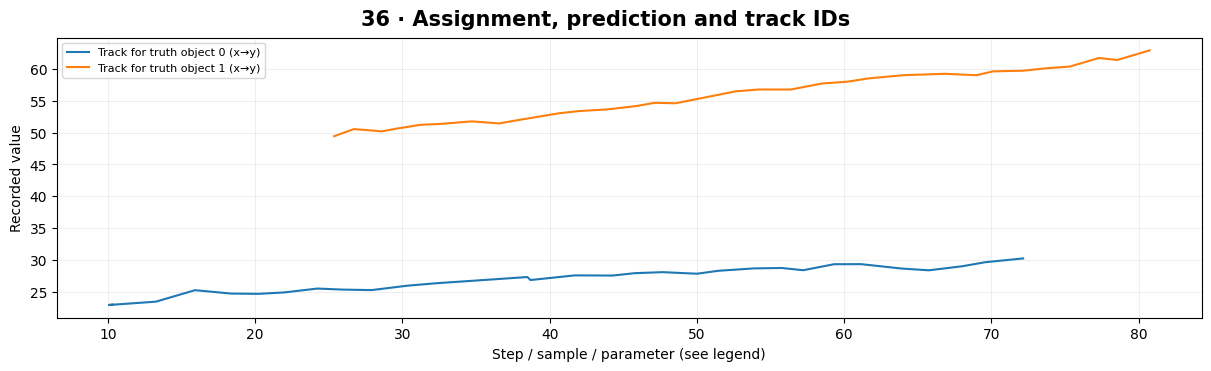

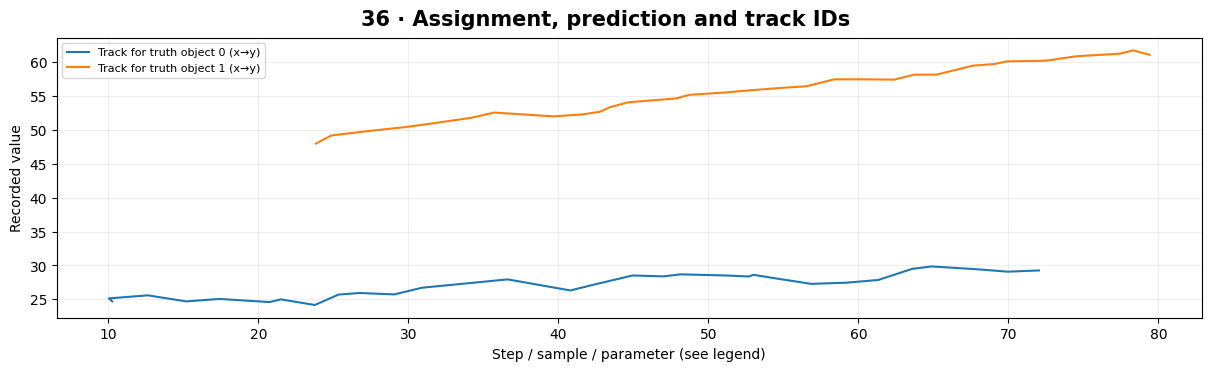

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Vehicle Tracking System**. Evaluate association separately from detection quality. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Track IDs are temporary anonymous identifiers, not person identities. A detector score is not a track survival probability.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Make two trajectories cross, remove observations briefly and compare the ID sequence before and after occlusion.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a vehicle tracker with timestamp-aware motion, line-crossing counts and a labeled identity-switch evaluation.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

The Hungarian algorithm finds a minimum-cost assignment in a cost matrix. Costs can use center distance, box overlap or appearance distance. Gating excludes implausible pairs before accepting assignments. Unmatched tracks predict through short gaps and expire after a declared lifetime.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **SORT, DeepSORT and evaluation** in this chapter.

[Primary reference](https://arxiv.org/abs/1602.00763) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)